## Table of Contents
1. [Load Packages](#setup)
- Load Pandas, Numpy, Matplotlib, and Seaborn packages
2. [Inspect Data](#inspect)
- Inspect data, descriptive statistics, see shape, evaluate data type, and non-null count
3. [Impute Missing Values](#impute)
- Impute bedrooms, bathrooms, sqft_living, and sqft_lot missing values
4. [Outlier Removal](#outlier)
- Identify extreme outliers (3.0 * IQR) from key columns and remove them
- Save the pre-outlier removal data for comparison in the modeling stage
5. [Feature Construction](#features)
- Construct features
- Drop unnecessary columns including ID, Date, Year Built, Year Renovated, Zipcode, Latitude, and Longitude
6. [Data Export](#export)
- Export the data to the visualization and modeling folders for further use
7. [Main Takeaways](#takeaways)

# Load Packages
<a id='setup'></a>

In [1]:
# Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inspect Data
<a id='inspect'></a>

In [2]:
# Import the dataset using pandas read_csv
df = pd.read_csv("house_sales.csv")

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Ensure head displays all columns
pd.set_option('display.max_columns', None)

# Display the top 5 rows
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Calculate descriptive statistics including Skewness and Kurtosis
stats = df.describe().T
stats['skew'] = df.select_dtypes(include=[np.number]).skew()
stats['kurtosis'] = df.select_dtypes(include=[np.number]).kurt()

print("--- Descriptive Statistics with Skewness ---")
display(stats[['mean', '50%', 'std', 'min', 'max', 'skew', 'kurtosis']])

--- Descriptive Statistics with Skewness ---


,mean,50%,std,min,max,skew,kurtosis
id,4580301520.864988,3904930410.0,2876565571.312057,1000102.0,9900000190.0,0.243329,-1.260542
date,2014-10-29 04:38:01.959931648,2014-10-16 00:00:00,NaN,2014-05-02 00:00:00,2015-05-27 00:00:00,NaN,NaN
price,540088.141767,450000.0,367127.196483,75000.0,7700000.0,4.024069,34.585540
bedrooms,3.372821,3.0,0.930711,0.0,33.0,2.022672,51.285212
bathrooms,2.113507,2.25,0.768913,0.0,8.0,0.504382,1.239547
sqft_living,2081.073697,1920.0,915.043176,290.0,12050.0,1.386147,4.104483
sqft_lot,15179.820507,7620.0,41486.172149,520.0,1651359.0,12.879729,280.300644
floors,1.494309,1.5,0.539989,1.0,3.5,0.616177,-0.484723
waterfront,0.007542,0.0,0.086517,0.0,1.0,11.385108,127.632494
view,0.234303,0.0,0.766318,0.0,4.0,3.395750,10.893022


In [4]:
# Display the shape of the dataframe
shape_df = pd.DataFrame(
    df.shape,
    index=["Rows", "Columns"],
    columns=["Count"],
)
display(shape_df)

# Display count by data type
dtype_df = df.dtypes.value_counts().to_frame(name="Number of Columns")
dtype_df.index.name = "Data Type"
display(dtype_df.reset_index())

,Count
Rows,21613
Columns,21


,Data Type,Number of Columns
0,int64,12
1,float64,8
2,datetime64[ns],1


In [5]:
# Display column number, column name, non-null count, and data type
info_df = pd.DataFrame(
    {
        "Column": df.columns,
        "Non-Null Count": df.notnull().sum().values,
        "Dtype": df.dtypes.values,
    }
)

display(info_df.reset_index(drop=True))

,Column,Non-Null Count,Dtype
0,id,21613,int64
1,date,21613,datetime64[ns]
2,price,21613,float64
3,bedrooms,20479,float64
4,bathrooms,20545,float64
5,sqft_living,20503,float64
6,sqft_lot,20569,float64
7,floors,21613,float64
8,waterfront,21613,int64
9,view,21613,int64


# Impute Missing Values
<a id='impute'></a>

Missing data was handled using variable-specific imputation strategies to preserve as many observations as possible while maintaining realistic data distributions.

1. Living space is imputed for all values by adding up living space above and living space below which have no nulls.
2. Lot space is imputed using the zipcode median.
3. A 33 bedroom outlier is replaced by the median for it's grade because its a clear outlier.
4. Zero bedroom and bathroom records are made into nulls for imputation.
5. Bedrooms are imputed by a living space per bedrooms ratio by grade. There is a fallback to a global living space per bedrooms value. Bedrooms are rounded to the nearest whole number.
6. Bathrooms are imputed by a living space per bathrooms ratio by grade. There is a fallback to a global living space per bathrooms value. Bathrooms are rounded to the nearest quarter value.

In [6]:
# Display dimensions with NA values
null_counts = df.isna().sum()
null_counts.index.name = "Column"
null_df = pd.DataFrame(null_counts[null_counts > 0], columns=["Count"])
display(null_df.reset_index())

,Column,Count
0,bedrooms,1134
1,bathrooms,1068
2,sqft_living,1110
3,sqft_lot,1044


In [7]:
# Impute sqft_living for all values by adding sqft_above and sqft_basement
df["sqft_living"] = df["sqft_above"] + df["sqft_basement"]

# Check NA values
assert (
    df["sqft_living"] - (df["sqft_above"] + df["sqft_basement"])
).sum() == 0
print("sqft_living fully reconstructed and validated.")

sqft_living fully reconstructed and validated.


In [8]:
# Impute missing values from sqft_lot by zip code median
zip_lot_medians = df.groupby('zipcode')['sqft_lot'].transform('median')
df['sqft_lot'] = df['sqft_lot'].fillna(zip_lot_medians)

In [9]:
# Identify the outlier (33 bedrooms) and replace with the median for its grade
outlier_grade = df.loc[df['bedrooms'] == 33, 'grade'].iloc[0]
grade_median = df[df['grade'] == outlier_grade]['bedrooms'].median()
df.loc[df['bedrooms'] == 33, 'bedrooms'] = grade_median

# Turn bed and bath zeroes into nulls for imputation
df.loc[df['bedrooms'] == 0, 'bedrooms'] = np.nan
df.loc[df['bathrooms'] == 0, 'bathrooms'] = np.nan

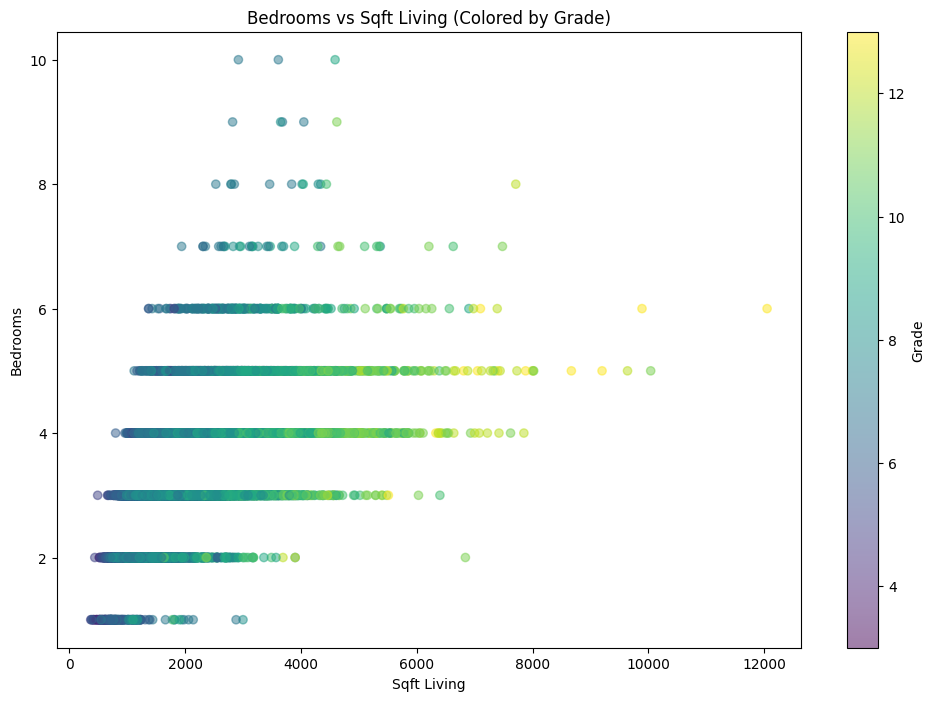

In [10]:
# Plot to look at the relationship between bedrooms, sqft_living, and grade
x = df['sqft_living']
y = df['bedrooms']
color = df['grade']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c=color, alpha=0.5)
plt.colorbar(label='Grade')
plt.xlabel('Sqft Living')
plt.ylabel('Bedrooms')
plt.title('Bedrooms vs Sqft Living (Colored by Grade)')
plt.show()

In [11]:
# Impute missing bedroom values from median sqft_living per bedrooms and grade

# Primary strategy - group by grade, median sqft_per_bed
df["sqft_per_bed"] = df["sqft_living"] / df["bedrooms"]
grade_bed_median = df.groupby("grade")["sqft_per_bed"].transform("median")

# Backup strategy - global bed median if primary does not work
# (one grade 1 example)
global_bed_median = (df["sqft_living"] / df["bedrooms"]).median()
imputed_beds = df["sqft_living"] / grade_bed_median.fillna(global_bed_median)
df["bedrooms"] = df["bedrooms"].fillna(imputed_beds).round().astype(int)

df = df.drop("sqft_per_bed", axis=1)

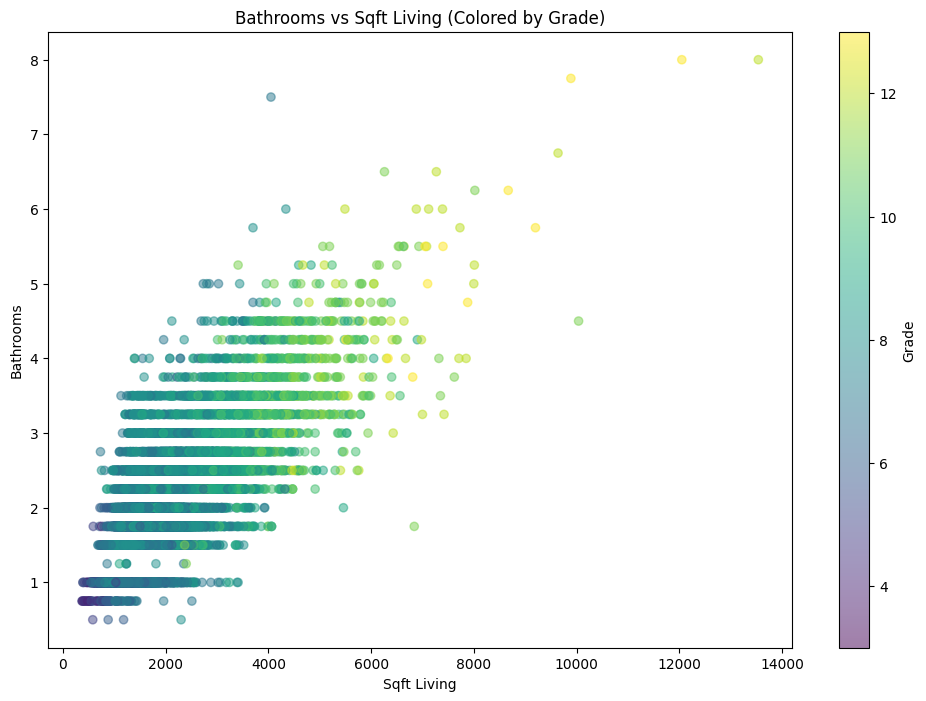

In [12]:
# Plot to look at the relationship between bathrooms, sqft_living, and grade
x = df["sqft_living"]
y = df["bathrooms"]
color = df["grade"]

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c=color, alpha=0.5)
plt.colorbar(label="Grade")
plt.xlabel("Sqft Living")
plt.ylabel("Bathrooms")
plt.title("Bathrooms vs Sqft Living (Colored by Grade)")
plt.show()

In [13]:
# Impute missing bathroom values from median sqft_living per bathrooms and grade

# Primary strategy - group by grade, median sqft_per_bath
df["sqft_per_bath"] = df["sqft_living"] / df["bathrooms"]
grade_bath_median = df.groupby("grade")["sqft_per_bath"].transform("median")

# Backup strategy - global bath median if primary does not work
# (one grade 1 example)
global_bath_median = (df["sqft_living"] / df["bathrooms"]).median()
imputed_baths = df["sqft_living"] / grade_bath_median.fillna(
    global_bath_median
)
df["bathrooms"] = df["bathrooms"].fillna(imputed_baths)

df = df.drop("sqft_per_bath", axis=1)

# Round bathrooms to a quarter point to match all data
df["bathrooms"] = (df["bathrooms"] * 4).round() / 4

# Check NA values
missing_columns = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot"]
missing_summary = df[missing_columns].isna().sum().to_frame(
    name="Missing Values"
)

missing_summary.index.name = "Column"
display(missing_summary.reset_index())

,Column,Missing Values
0,bedrooms,0
1,bathrooms,0
2,sqft_living,0
3,sqft_lot,0


In [14]:
# Check summary metrics after imputing missing values
pd.set_option("display.float_format", "{:,.2f}".format)
df.describe()

Column,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00",21613,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86",2014-10-29 04:38:01.959931648,"540,088.14",3.38,2.11,"2,079.90","14,853.75",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
min,"1,000,102.00",2014-05-02 00:00:00,"75,000.00",1.00,0.25,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00",2014-07-22 00:00:00,"321,950.00",3.00,1.50,"1,427.00","5,080.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00",2014-10-16 00:00:00,"450,000.00",3.00,2.25,"1,910.00","7,663.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00",2015-02-17 00:00:00,"645,000.00",4.00,2.50,"2,550.00","10,500.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00",2015-05-27 00:00:00,"7,700,000.00",11.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"
std,"2,876,565,571.31",NaN,"367,127.20",0.91,0.77,918.44,"40,511.67",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"


In [15]:
# Copy the df for comparison with outliers
# Adding feature engineered columns in a later step.
df_pre_outlier_removal = df.copy()

# Outlier Removal
<a id='outlier'></a>

- Outliers are removed if they are extreme, meaning they are 3.0 * IQR outside of Q1 and Q3.
- A 3.0 × IQR threshold was used instead of the traditional 1.5 × IQR to focus on removing only extreme outliers while preserving legitimate high-value observations in a naturally skewed housing dataset.

- Only certain columns were considered for outlier removal.
    - Bathrooms, Lot Space, View, Waterfront, Year Renovated, and Latitude are all valid columns that describe important information, so removing outliers here is not valid.
    - Similarly, it doesn't make sense to remove an outlier for Living Space 15 or Lot Space 15 since those represent an adjoining properties space and not that individual properties space.
    - Price, Bedrooms, Living Space, Grade, Living Space Above, and Living Space Basement are considered for outlier removal.
    - Many variables that are heavily skewed like Lot Space and Price will be logged, which retains more data but handles outliers and makes the distributions more uniform and better for regression.

In [16]:
# Define the columns you want to filter
cols_to_filter = [
    "price",
    "bedrooms",
    "sqft_living",
    "grade",
    "sqft_above",
    "sqft_basement",
]

# Identify outliers using the 3.0 * IQR rule
# We calculate bounds based on the original dataframe (df)
q1 = df[cols_to_filter].quantile(0.25)
q3 = df[cols_to_filter].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3.0 * iqr
upper_bound = q3 + 3.0 * iqr

# Create a boolean mask where True means it is an extreme outlier
outlier_mask = (df[cols_to_filter] < lower_bound) | (
    df[cols_to_filter] > upper_bound
)

# Identify indices where any of the specified columns have an outlier
to_drop_indices = outlier_mask.any(axis=1)
df_no_outliers = df[~to_drop_indices].copy()

# Print the impact of dropping rows
rows_dropped = len(df) - len(df_no_outliers)
percentage_dropped = round((rows_dropped / len(df)) * 100, 2)

print(
    f"The number of rows dropped since the original dataframe: "
    f"{rows_dropped}"
)
print(
    f"The percentage of rows dropped since the original dataframe: "
    f"{percentage_dropped}%"
)

# Final verification: Check for remaining outliers in the new dataframe
# This uses the original bounds to see if any values in the new df still
# exceed them
remaining_outlier_counts = {}

for col in df_no_outliers.select_dtypes(include="number").columns:
    # Recalculate bounds per column if not in our filter list,
    # or reuse original bounds if it was in the list
    c_q1 = df[col].quantile(0.25)
    c_q3 = df[col].quantile(0.75)
    c_iqr = c_q3 - c_q1

    c_lower = c_q1 - 3.0 * c_iqr
    c_upper = c_q3 + 3.0 * c_iqr

    count = ((df_no_outliers[col] < c_lower) | (
        df_no_outliers[col] > c_upper
    )).sum()
    if count > 0:
        remaining_outlier_counts[col] = count

# Display the summary table of remaining outliers
outlier_summary = pd.DataFrame.from_dict(
    remaining_outlier_counts,
    orient="index",
    columns=["Remaining Extreme Outliers"],
)
outlier_summary.index.name = "Column"

display(outlier_summary.reset_index())
display(df_no_outliers.describe(include="number"))

The number of rows dropped since the original dataframe: 517
The percentage of rows dropped since the original dataframe: 2.39%


,Column,Remaining Extreme Outliers
0,bathrooms,1
1,sqft_lot,1658
2,waterfront,91
3,view,1849
4,yr_renovated,845
5,long,17
6,sqft_living15,8
7,sqft_lot15,1517


Column,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00"
mean,"4,591,852,648.99","503,173.98",3.35,2.08,"2,017.88","14,406.88",1.49,0.00,0.20,3.41,7.59,"1,739.88",278.00,"1,970.87",79.94,"98,078.38",47.56,-122.21,"1,952.83","12,487.42"
std,"2,878,046,900.87","253,387.11",0.89,0.72,809.70,"38,819.07",0.54,0.07,0.70,0.65,1.09,750.75,419.40,29.29,391.35,53.41,0.14,0.14,643.59,"26,353.99"
min,"1,000,102.00","78,000.00",1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,4.00,370.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,125,319,771.00","319,990.00",3.00,1.50,"1,410.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,180.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,480.00","5,080.00"
50%,"3,905,005,275.00","445,000.00",3.00,2.25,"1,890.00","7,600.00",1.00,0.00,0.00,3.00,7.00,"1,540.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,820.00","7,560.00"
75%,"7,334,500,097.50","625,000.00",4.00,2.50,"2,500.00","10,306.50",2.00,0.00,0.00,4.00,8.00,"2,157.00",540.00,"1,996.00",0.00,"98,118.00",47.68,-122.12,"2,320.00","9,975.00"
max,"9,900,000,190.00","1,612,500.00",7.00,5.75,"5,860.00","1,651,359.00",3.50,1.00,4.00,5.00,11.00,"5,250.00","2,220.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"5,790.00","871,200.00"


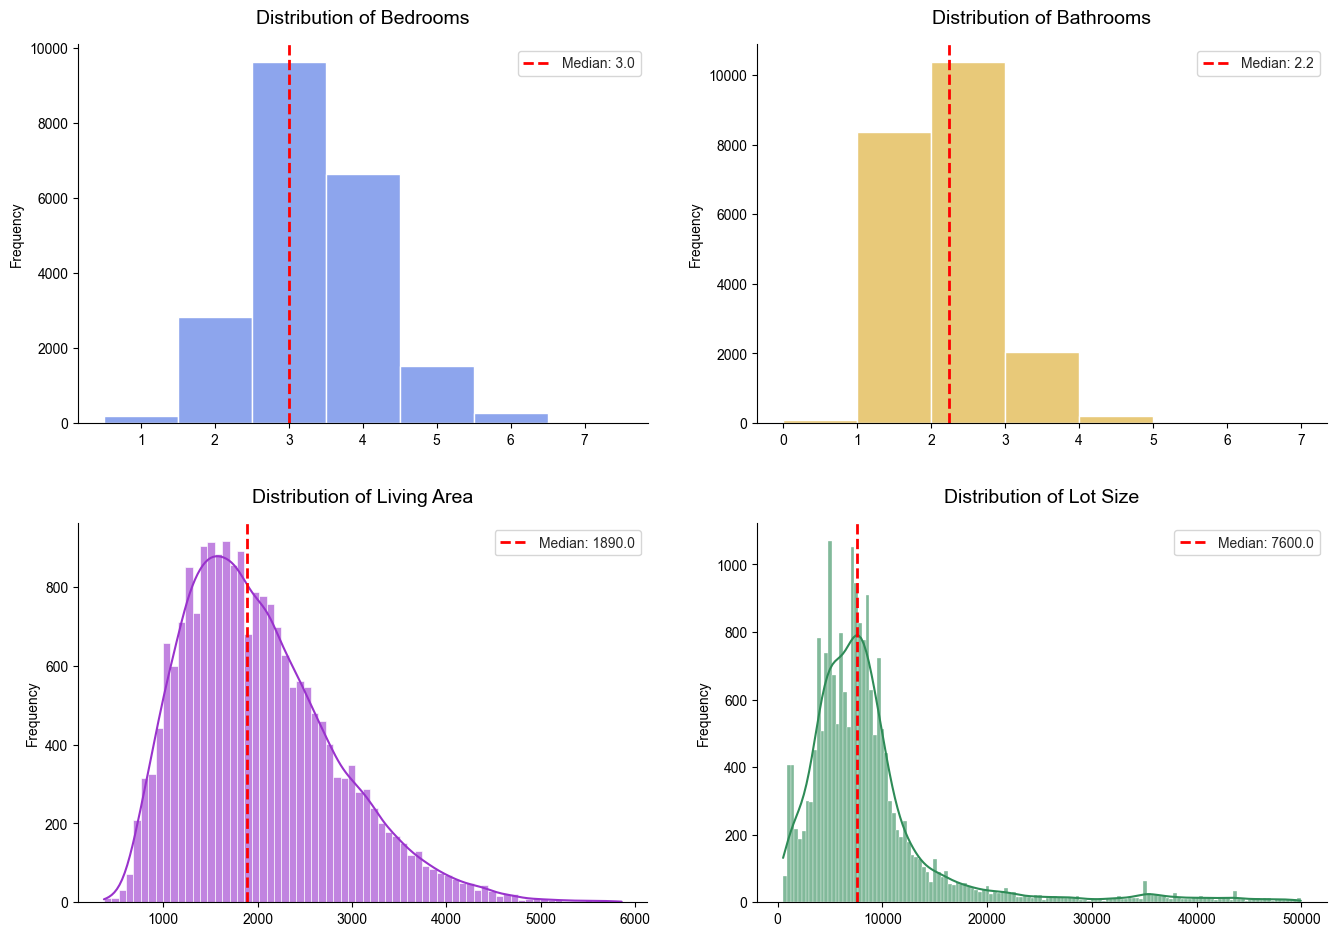

In [17]:
settings = [
    ("bedrooms", "Bedrooms", "royalblue", 10),
    ("bathrooms", "Bathrooms", "goldenrod", 6),
    ("sqft_living", "Living Area", "darkorchid", 6000),
    ("sqft_lot", "Lot Size", "seagreen", 50000),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_style("white")  # Clean white background

for ax, (col, title, color, limit) in zip(axes.flatten(), settings):
    # Filter data for visualization only
    # (prevents outliers from squishing the plot)
    plot_data = (
        df_no_outliers[df_no_outliers[col] <= limit][col]
        if limit
        else df_no_outliers[col]
    )

    # Use discrete=True for counts to center bars on integers
    is_discrete = col in ["bedrooms", "bathrooms"]

    sns.histplot(
        plot_data,
        kde=not is_discrete,
        ax=ax,
        color=color,
        alpha=0.6,
        discrete=is_discrete,
        edgecolor="white",
    )

    # Add median line
    median_val = df_no_outliers[col].median()
    ax.axvline(
        median_val,
        color="red",
        ls="--",
        lw=2,
        label=f"Median: {median_val:.1f}",
    )

    # Professional formatting
    ax.set_title(f"Distribution of {title}", fontsize=14, pad=15)
    ax.set_xlabel(None)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend(frameon=True)
    sns.despine()  # Remove top and right borders

plt.tight_layout(pad=3.0)
plt.show()

# Feature Construction
<a id='features'></a>
- Construct features including:
    - Renovation Boolean
    - Living Space to Lot Space Ratio
    - Sale Month
    - Grade Level
    - Condition Level
    - House Age
        - Standard House Age
        - Mean Centered House Age
        - Mean Centered House Age Squared
    - Logged Columns:
        - Price
        - Living Space
        - Living Space Above
        - Living Space Basement (0 kept as 0)
        - Lot Space
        - Lot Space 15

In [18]:
# Feature construction for data with and without outliers
dfs = [df_pre_outlier_removal, df_no_outliers]

for d in dfs:
    # Construct house age from date and year built
    d["house_age"] = (d["date"].dt.year - d["yr_built"]).clip(lower=0)
    d["renovated_bool"] = d["yr_renovated"].apply(
    lambda x: 1 if x > 0 else 0
)

    # Create a few logged variables for visualization and analysis
    # Cannot log sqft_basement because of legitimate zero values
    log_cols = [
        "price",
        "sqft_living",
        "sqft_above",
        "sqft_basement",
        "sqft_lot",
        "sqft_lot15",
        "sqft_living15",
    ]
    for col in log_cols:
        d[f"log_{col}"] = np.log1p(d[col]).round(4)

    # Living to lot ratio
    d["living_lot_ratio"] = (d["sqft_living"] / d["sqft_lot"]).round(3)

    # Month of sale (that may influence the price)
    d["sale_month"] = d["date"].dt.month

    # Grade/condition groups - lets visualize these in the next step
    # to see if these are meaningful or if we can improve them
    d["grade_level"] = pd.cut(
        d["grade"],
        bins=[0, 6, 9, 13],
        labels=["Low", "Mid", "High"],
    )
    d["condition_level"] = pd.cut(
        d["condition"],
        bins=[0, 2, 3, 5],
        labels=["Poor", "Average", "Good"],
    )

    # Create house age features to capture non-linear relationships
    # with house age
    age_mean = d["house_age"].mean()
    d["house_age_c"] = (d["house_age"] - age_mean).round(2)
    d["house_age_c_sq"] = (d["house_age_c"] ** 2).round(2)

In [19]:
# Columns to drop
cols_to_drop = [
    "id",
    "date",
    "yr_built",
    "yr_renovated",
    "zipcode",
    "lat",
    "long",
]

dfs = [df_pre_outlier_removal, df_no_outliers]

for i, d in enumerate(dfs):
    df_name = "df_pre_outlier_removal" if i == 0 else "df_no_outliers"
    d.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Final shape for {df_name}: {d.shape}")

Final shape for df_pre_outlier_removal: (21613, 29)
Final shape for df_no_outliers: (21096, 29)


# Data Export
<a id='export'></a>

In [20]:
# Save the data frames to the viz step

df_no_outliers.to_csv(
    "../2) Visualization/cleaned_house_sales.csv",
    index=False,
)
df_pre_outlier_removal.to_csv(
    "../2) Visualization/cleaned_house_sales_with_outliers.csv",
    index=False,
)
df_no_outliers.to_csv(
    "../3) Model/cleaned_house_sales.csv",
    index=False,
)
df_pre_outlier_removal.to_csv(
    "../3) Model/cleaned_house_sales_with_outliers.csv",
    index=False,
)

print("Files saved successfully to the Vis and Model folder!")

print("--- Data with no outliers ---")
display(df_no_outliers.head())
print("--- Data with outliers ---")
df_pre_outlier_removal.head()

Files saved successfully to the Vis and Model folder!
--- Data with no outliers ---


Column,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age,renovated_bool,log_price,log_sqft_living,log_sqft_above,log_sqft_basement,log_sqft_lot,log_sqft_lot15,log_sqft_living15,living_lot_ratio,sale_month,grade_level,condition_level,house_age_c,house_age_c_sq
0,"221,900.00",3,1.00,1180,"5,650.00",1.00,0,0,3,7,1180,0,1340,5650,59,0,12.31,7.07,7.07,0.00,8.64,8.64,7.20,0.21,10,Mid,Average,15.55,241.80
1,"538,000.00",3,2.25,2570,"7,242.00",2.00,0,0,3,7,2170,400,1690,7639,63,1,13.20,7.85,7.68,5.99,8.89,8.94,7.43,0.35,12,Mid,Average,19.55,382.20
2,"180,000.00",2,1.00,770,"10,000.00",1.00,0,0,3,6,770,0,2720,8062,82,0,12.10,6.65,6.65,0.00,9.21,8.99,7.91,0.08,2,Low,Average,38.55,"1,486.10"
3,"604,000.00",4,3.00,1960,"5,000.00",1.00,0,0,5,7,1050,910,1360,5000,49,0,13.31,7.58,6.96,6.81,8.52,8.52,7.22,0.39,12,Mid,Good,5.55,30.80
4,"510,000.00",3,2.00,1680,"8,080.00",1.00,0,0,3,8,1680,0,1800,7503,28,0,13.14,7.43,7.43,0.00,9.00,8.92,7.50,0.21,2,Mid,Average,-15.45,238.70


--- Data with outliers ---


Column,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age,renovated_bool,log_price,log_sqft_living,log_sqft_above,log_sqft_basement,log_sqft_lot,log_sqft_lot15,log_sqft_living15,living_lot_ratio,sale_month,grade_level,condition_level,house_age_c,house_age_c_sq
0,"221,900.00",3,1.00,1180,"5,650.00",1.00,0,0,3,7,1180,0,1340,5650,59,0,12.31,7.07,7.07,0.00,8.64,8.64,7.20,0.21,10,Mid,Average,15.68,245.86
1,"538,000.00",3,2.25,2570,"7,242.00",2.00,0,0,3,7,2170,400,1690,7639,63,1,13.20,7.85,7.68,5.99,8.89,8.94,7.43,0.35,12,Mid,Average,19.68,387.30
2,"180,000.00",2,1.00,770,"10,000.00",1.00,0,0,3,6,770,0,2720,8062,82,0,12.10,6.65,6.65,0.00,9.21,8.99,7.91,0.08,2,Low,Average,38.68,"1,496.14"
3,"604,000.00",4,3.00,1960,"5,000.00",1.00,0,0,5,7,1050,910,1360,5000,49,0,13.31,7.58,6.96,6.81,8.52,8.52,7.22,0.39,12,Mid,Good,5.68,32.26
4,"510,000.00",3,2.00,1680,"8,080.00",1.00,0,0,3,8,1680,0,1800,7503,28,0,13.14,7.43,7.43,0.00,9.00,8.92,7.50,0.21,2,Mid,Average,-15.32,234.70


# Main Takeaways
<a id='takeaways'></a>

1. Missing values were limited to a small subset of variables and were imputed using context-specific methods to preserve data integrity.
2. Outlier removal was restricted to select variables to avoid excluding valid observations, resulting in the removal of only 2.39% of the data.
3. Additional features were constructed to capture relationships not directly represented in the original dataset.